## NASA GISS Annual Earth Temperature Anomaly

NASA GISS Surface Temperature Analysis (GISTEMP v4) - [data.giss.nasa.gov/gistemp/](https://data.giss.nasa.gov/gistemp/).

Data are updated annually through the most recent complete year. Retrieve the latest version of this CSV
file:

* [ZonAnn.Ts+dSST.csv](https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv)

This file must be in the same directory as this notebook.  The code below will try to retrieve the most
recent data if the file is more than 1 day old, or you can force update with the `updateFile` variable
below.

In cas they have reorganized the GISS website, these data are the "Combined Land-Surface Air and Sea-Surface
Water Temperature Anomalies (Land-Ocean Temperature Index, L-OTI) Zonal annual means, 1880-present, updated
through most recent complete year".

Creates a PNG file named `AnnGlobAnomaly_<CCYY>.png`, where `<CCYY>` is the most recent complete year, derived
from the last entry in the CSV file.

In [1]:
%matplotlib inline

import os, time
import urllib.request

import sys, math

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

For this plot an 3/2 aspect ratio looks best, but you can change to suit.

In [2]:
aspect = 3/2 # 4/3

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
axisFontSize = np.rint(axisFontSize/scaleFac)
labelFontSize = np.rint(labelFontSize/scaleFac)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'


## GISS Data

Source data in file `ZonAnn.Ts+dSST_Jan2022.csv` which has many columns.  We will just plot the global
average, can also extract and plot by hemisphere or latitude zones.

You can force update by setting `updateFile = True`

In [3]:
dataURL = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv'
gissFile = 'ZonAnn.Ts+dSST.csv'
updateFile = False

oldFile = False
if not os.path.exists(gissFile):
    updateFile = True
    oldFile = False
else:
    oldFile = True
    fileAge = (time.time() - os.path.getmtime(gissFile))/86400.0
    if fileAge >= 1.0:
        updateFile = True
        
if updateFile:
    try:
        with urllib.request.urlopen(dataURL) as wf:
            raw = wf.read().decode('utf-8')
    except:
        if oldFile:
            print('Problem retrieving updated data, using old file')
        else:
            print('Problem retrieving updated data, no old file to use')
            print('Try retrieving by hand and re-run')
    if oldFile:
        os.remove(gissFile)
    f = open(gissFile,'w')
    f.write(raw)
    f.close()   
    print('Retrieved updated temperature data from NASA GISS')
else:
    print('Temperature data from NASA GISS are up-to-date (<1d old)')



data = pd.read_csv(gissFile)
year = np.array(data['Year'])
tempAnom = np.array(data['Glob'])  # global temperature anomaly

plotFile = f'AnnGlobAnomaly_{year[-1]}.png' 


Retrieved updated temperature data from NASA GISS


### Make the plot

Plot annual temperature anomaly (departure from the common baseline from 1951-1980).

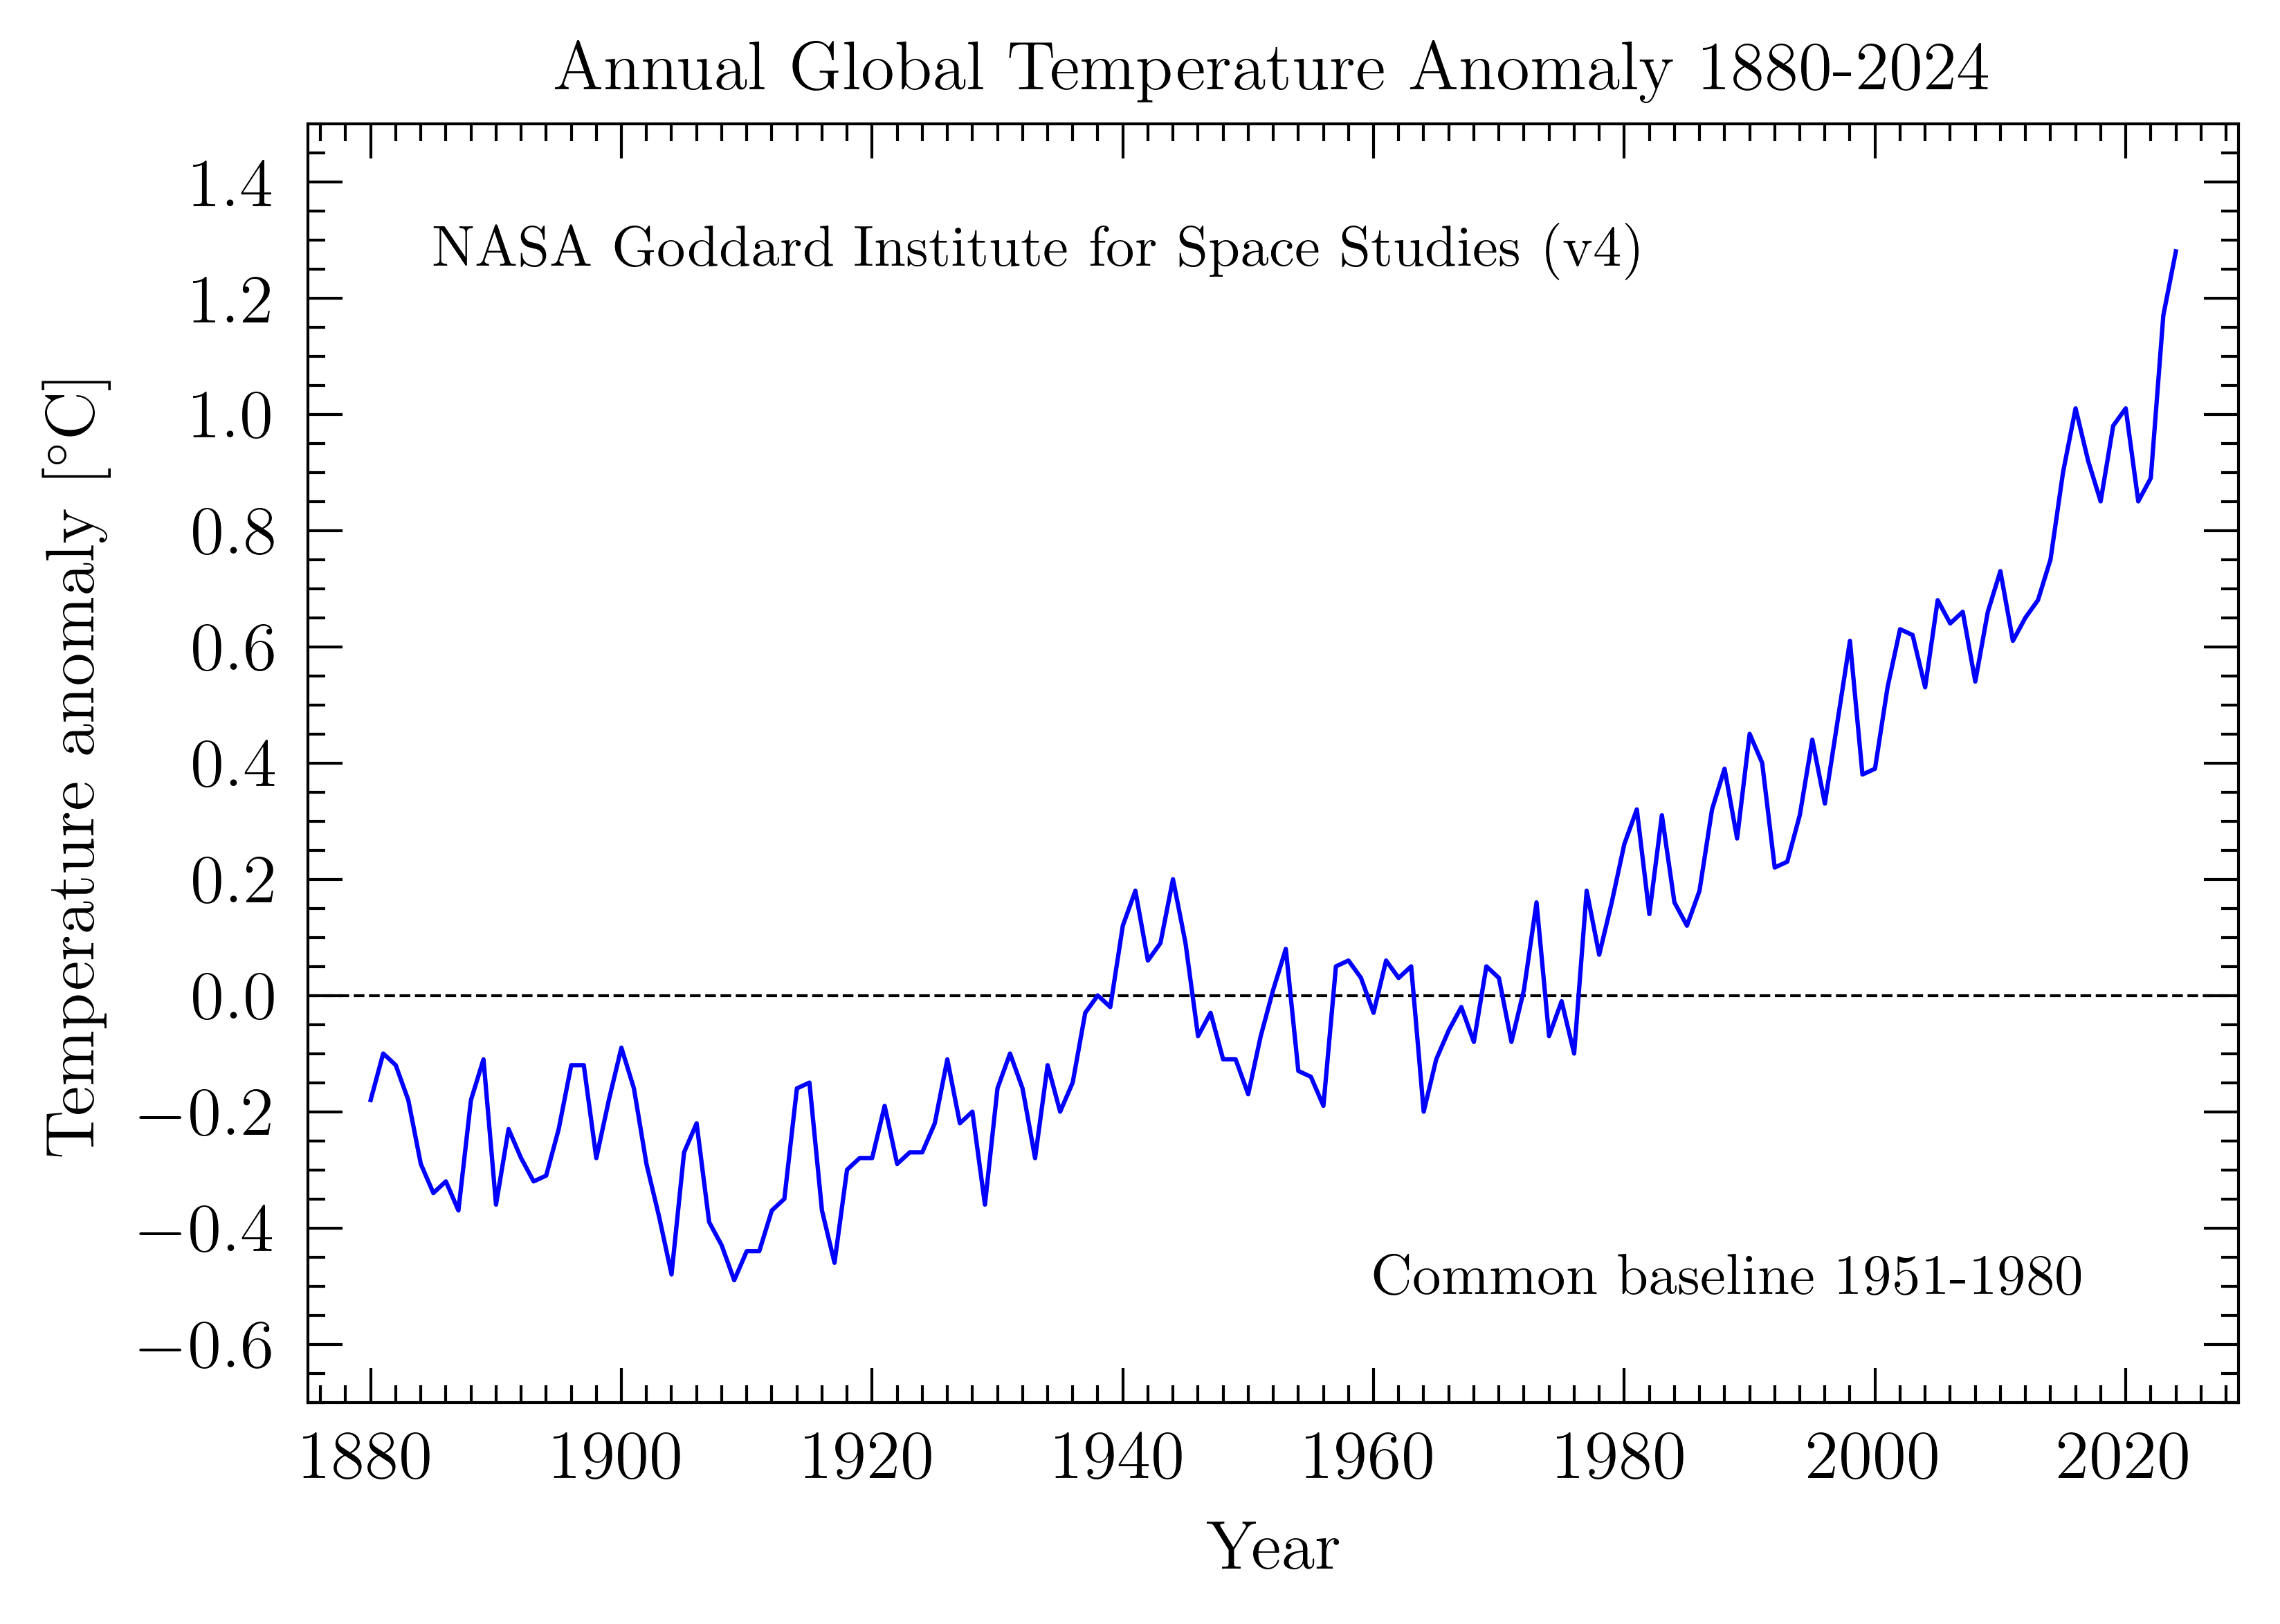

In [4]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

yrMin = year[0]-5
yrMax = year[-1]+5

tMin = np.min(tempAnom)
tMax = np.max(tempAnom)
dT = tMax - tMin
tempMin = int(10*(tMin-0.15*dT))/10.0
tempMax = int(10*(tMax+0.15*dT))/10.0

ax.set_xlim(yrMin,yrMax)
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.set_xlabel(r'Year',fontsize=axisFontSize)

ax.set_ylim(tempMin,tempMax)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_ylabel(r'Temperature anomaly [$^\circ$C]',fontsize=axisFontSize)

ax.plot(year,tempAnom,ls='-',color='blue',lw=0.75,zorder=10)

ax.hlines(0.0,yrMin,yrMax,ls=['--'],colors=['black'],lw=0.5,zorder=8)

# Annotations

ax.set_title(f'Annual Global Temperature Anomaly {year[0]}-{year[-1]}',fontsize=axisFontSize)
ax.text(1885,tMax,'NASA Goddard Institute for Space Studies (v4)',va='center',ha='left',fontsize=10)
ax.text(1960,tMin,'Common baseline 1951-1980',va='center',ha='left',fontsize=10)

# Make the plot

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')